# Interpolación

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scripts import get_and_plot_interpolated_for_new_n, fft_interpoladas_y_original
import seaborn as sns
sns.set_style('darkgrid')

In [147]:
ventas_locales_AB = pd.read_csv('data.csv')
ventas_locales_AB.head()

,X,t,localA,localB
0,1,40,1.345,1.170
1,2,41,0.937,1.397
2,3,42,1.523,0.628
3,4,43,2.448,2.080
4,5,44,2.526,0.079


In [148]:
N = len(ventas_locales_AB)
print(f"Tamaño de muestra: {N}")

Tamaño de muestra: 21


## 1. Aumentar frecuencia de muestreo

In [149]:
t = ventas_locales_AB['t'].values
localA = ventas_locales_AB['localB'].values

new_n = 4 * N
t_new = np.linspace(t.min(), t.max(), new_n)
print(f"Nuevo tamaño de muestra: {new_n}")

Nuevo tamaño de muestra: 84


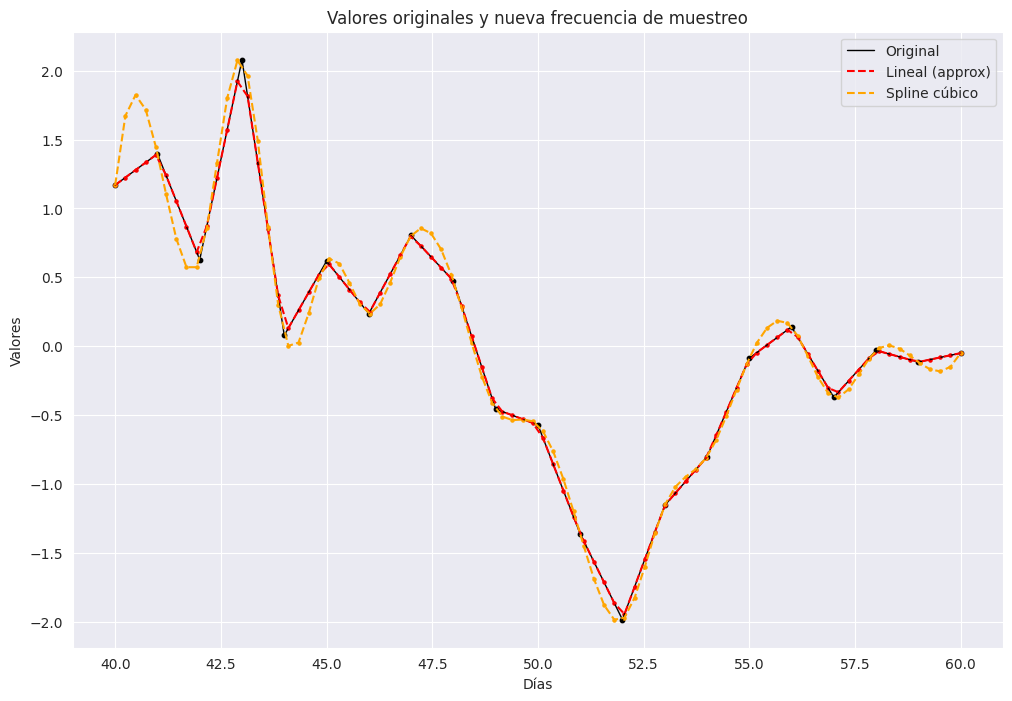

In [150]:
localA_interp_lineal, localA_interp_cubica = get_and_plot_interpolated_for_new_n(t, t_new, localA)

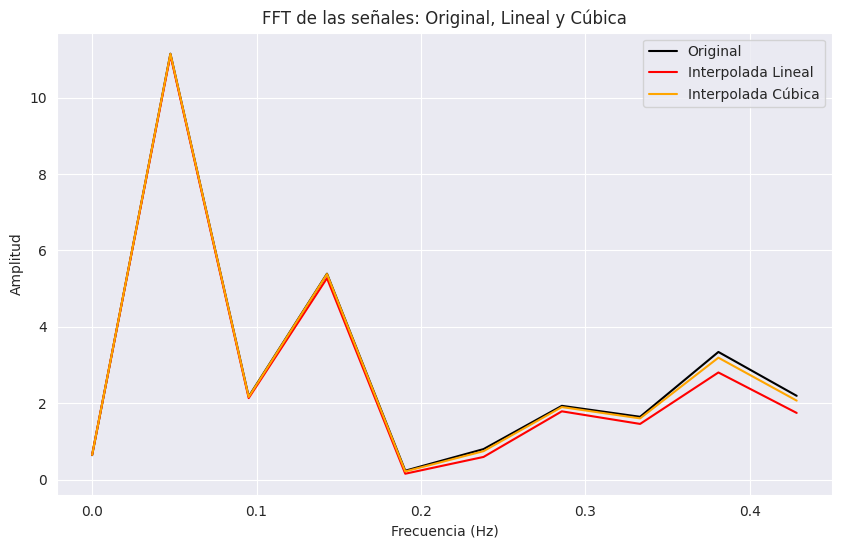

In [151]:
fft_interpoladas_y_original(t, t_new, localA, localA_interp_lineal, localA_interp_cubica)

El aumento de frecuencia de muestreo en la interpolación **no añadió componentes al espectro frecuencia**.

## 2. Disminuir frecuencia de muestreo

In [152]:
new_n = N // 3
t_new = np.linspace(t.min(), t.max(), new_n)
print(f'Nueva frecuencia de muestreo: {new_n}')

Nueva frecuencia de muestreo: 7


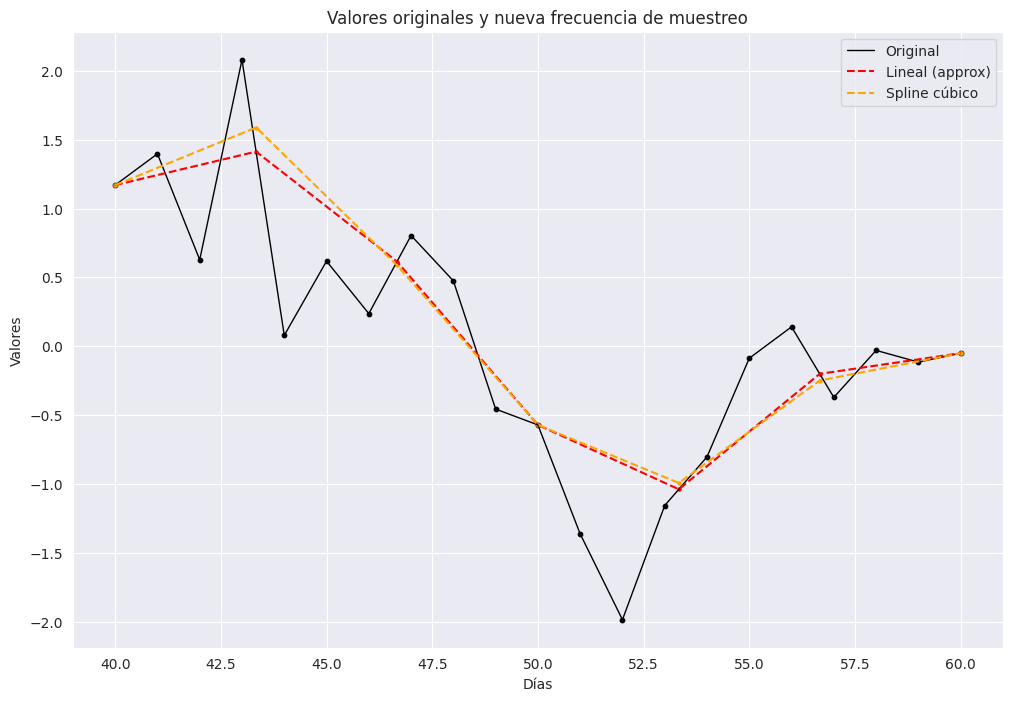

In [153]:
localA_interp_lineal, localA_interp_cubica = get_and_plot_interpolated_for_new_n(t, t_new, localA)

Similar a un **filtro pasa-bajos**, como en la Moving Average.

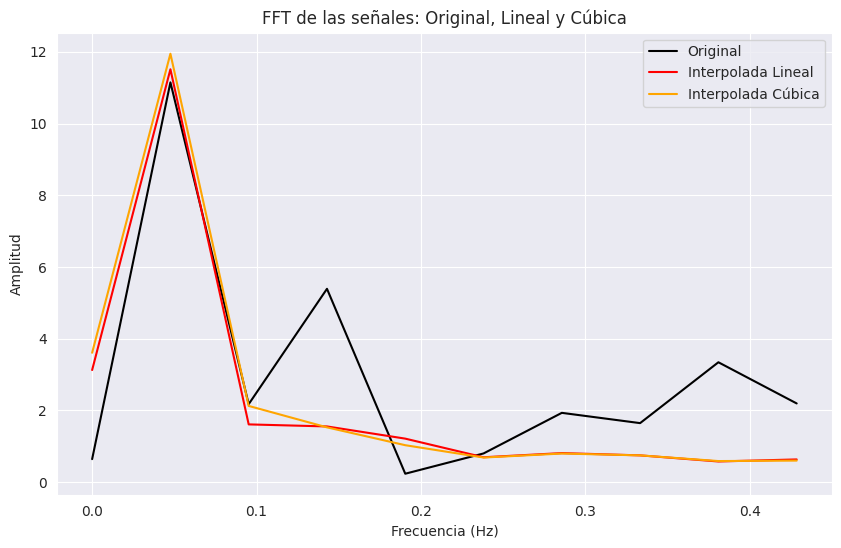

In [154]:
fft_interpoladas_y_original(t, t_new, localA, localA_interp_lineal, localA_interp_cubica)

### Disminución de frecuencia de muestreo sobre original filtrada con pasa-bajos (MA)

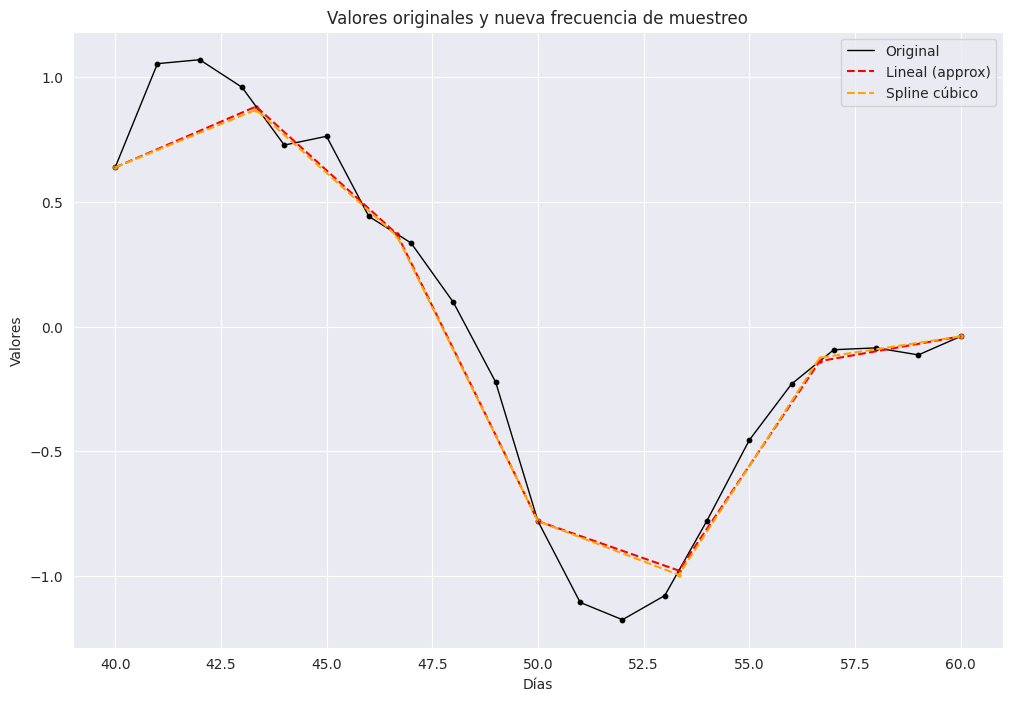

In [155]:
localA_filtro_pb = np.convolve(localA, np.ones(5)/5, mode='same')
localA_interp_lineal, localA_interp_cubica = get_and_plot_interpolated_for_new_n(t, t_new, localA_filtro_pb)

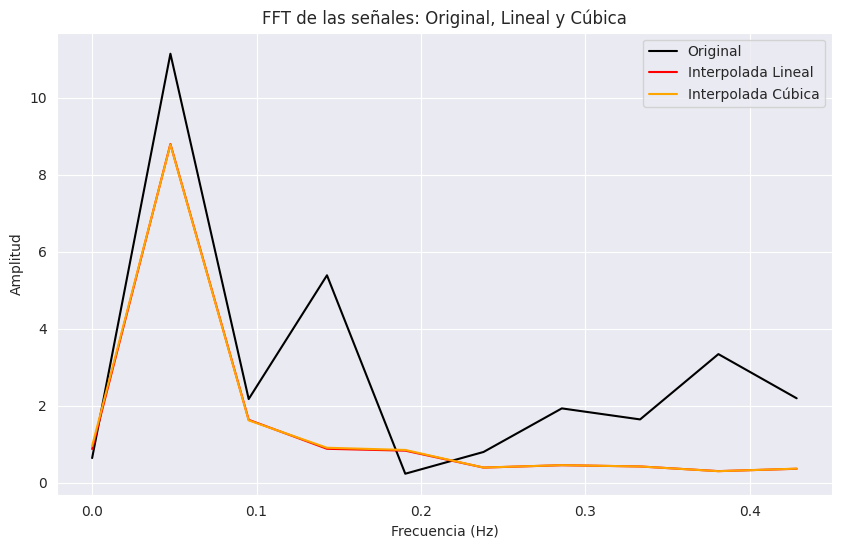

In [156]:
fft_interpoladas_y_original(t, t_new, localA, localA_interp_lineal, localA_interp_cubica)